# NeqSim Field-Development Framework Map

This notebook supports Chapter 24. It links the public NeqSim field-development strategy and integrated framework to the course chapters, then runs a smoke test of the Python-accessible field-development APIs used in Chapters 11, 13 and 20.


In [ ]:
from pathlib import Path
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

FIGURES_DIR = NOTEBOOK_DIR.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass
ArrayList = JClass("java.util.ArrayList")

FieldConcept = JClass("neqsim.process.fielddevelopment.concept.FieldConcept")
ReservoirInput = JClass("neqsim.process.fielddevelopment.concept.ReservoirInput")
WellsInput = JClass("neqsim.process.fielddevelopment.concept.WellsInput")
InfrastructureInput = JClass("neqsim.process.fielddevelopment.concept.InfrastructureInput")
ConceptEvaluator = JClass("neqsim.process.fielddevelopment.evaluation.ConceptEvaluator")
DevelopmentOptionRanker = JClass("neqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker")
Criterion = JClass("neqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker$Criterion")
FlowAssuranceScreener = JClass("neqsim.process.fielddevelopment.screening.FlowAssuranceScreener")
TiebackAnalyzer = JClass("neqsim.process.fielddevelopment.tieback.TiebackAnalyzer")
HostFacility = JClass("neqsim.process.fielddevelopment.tieback.HostFacility")
SubseaProductionSystem = JClass("neqsim.process.fielddevelopment.subsea.SubseaProductionSystem")
SubseaArchitecture = JClass("neqsim.process.fielddevelopment.subsea.SubseaProductionSystem$SubseaArchitecture")
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
WellSystem = JClass("neqsim.process.equipment.reservoir.WellSystem")
IPRModel = JClass("neqsim.process.equipment.reservoir.WellSystem$IPRModel")
NetworkSolver = JClass("neqsim.process.fielddevelopment.network.NetworkSolver")
SolutionMode = JClass("neqsim.process.fielddevelopment.network.NetworkSolver$SolutionMode")
GasLiftCalculator = JClass("neqsim.process.fielddevelopment.screening.GasLiftCalculator")
CashFlowEngine = JClass("neqsim.process.fielddevelopment.economics.CashFlowEngine")
ProductionProfile = JClass("neqsim.process.util.fielddevelopment.ProductionProfile")
DeclineParameters = JClass("neqsim.process.util.fielddevelopment.ProductionProfile$DeclineParameters")
DeclineType = JClass("neqsim.process.util.fielddevelopment.ProductionProfile$DeclineType")

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures: {FIGURES_DIR}")


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Figures: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\chapters\ch24_computational_tools_neqsim\figures


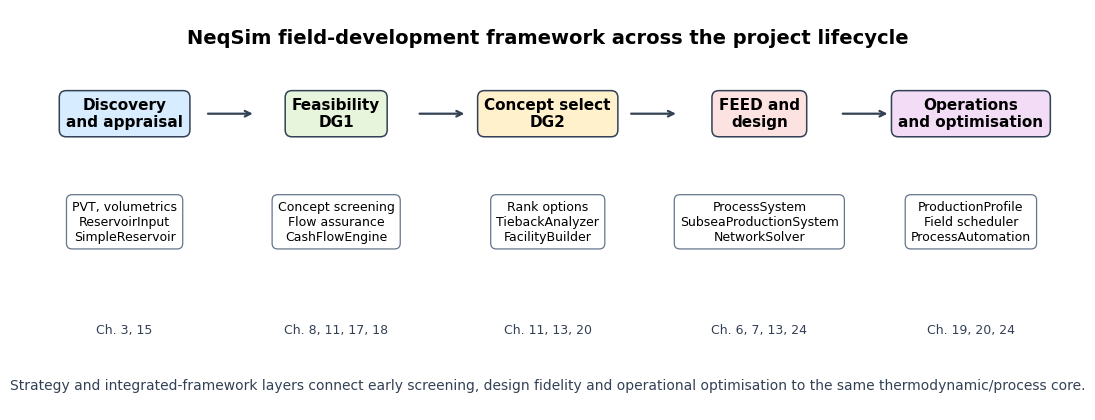

In [2]:
phases = [
    ("Discovery\nand appraisal", "PVT, volumetrics\nReservoirInput\nSimpleReservoir", "Ch. 3, 15"),
    ("Feasibility\nDG1", "Concept screening\nFlow assurance\nCashFlowEngine", "Ch. 8, 11, 17, 18"),
    ("Concept select\nDG2", "Rank options\nTiebackAnalyzer\nFacilityBuilder", "Ch. 11, 13, 20"),
    ("FEED and\ndesign", "ProcessSystem\nSubseaProductionSystem\nNetworkSolver", "Ch. 6, 7, 13, 24"),
    ("Operations\nand optimisation", "ProductionProfile\nField scheduler\nProcessAutomation", "Ch. 19, 20, 24"),
]

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.axis("off")
xs = [0.08, 0.29, 0.50, 0.71, 0.92]
colors = ["#d8ecff", "#e7f5dc", "#fff1cc", "#fde2e2", "#f3ddf6"]
for i, ((phase, classes, chapters), x, color) in enumerate(zip(phases, xs, colors)):
    ax.text(x, 0.74, phase, ha="center", va="center", fontsize=11, weight="bold",
            bbox=dict(boxstyle="round,pad=0.45", facecolor=color, edgecolor="#334155", linewidth=1.1))
    ax.text(x, 0.47, classes, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#64748b", linewidth=0.9))
    ax.text(x, 0.20, chapters, ha="center", va="center", fontsize=9, color="#334155")
    if i < len(xs) - 1:
        ax.annotate("", xy=(xs[i+1] - 0.08, 0.74), xytext=(x + 0.08, 0.74),
                    arrowprops=dict(arrowstyle="->", color="#334155", lw=1.6))

ax.text(0.5, 0.93, "NeqSim field-development framework across the project lifecycle",
        ha="center", va="center", fontsize=14, weight="bold")
ax.text(0.5, 0.06,
        "Strategy and integrated-framework layers connect early screening, design fidelity and operational optimisation to the same thermodynamic/process core.",
        ha="center", va="center", fontsize=10, color="#334155")
fig.savefig(FIGURES_DIR / "ch24_field_development_neqsim_framework.png", dpi=160, bbox_inches="tight")
plt.show()


In [3]:
smoke = {}

concept = FieldConcept.builder("Framework smoke concept") \
    .reservoir(ReservoirInput.leanGas().gor(10000.0).co2Percent(1.5).h2sPercent(0.0).build()) \
    .wells(WellsInput.builder().producerCount(3).tubeheadPressure(100.0).ratePerWell(1.0e6, "Sm3/d").build()) \
    .infrastructure(InfrastructureInput.subseaTieback().tiebackLength(25.0).waterDepth(300.0).exportPressure(180.0).build()) \
    .build()

kpis = ConceptEvaluator().evaluate(concept)
fa_report = FlowAssuranceScreener().quickScreen(concept)
smoke["FieldConcept / ConceptEvaluator"] = f"score={kpis.getOverallScore():.3f}, capex={kpis.getTotalCapexMUSD():.1f} MUSD"
smoke["FlowAssuranceScreener"] = str(fa_report.getOverallResult())

ranker = DevelopmentOptionRanker()
ranker.setWeightProfile("balanced")
option = ranker.addOption("Tieback")
option.setScore(Criterion.NPV, 650.0)
option.setScore(Criterion.CO2_INTENSITY, 10.0)
option.setScore(Criterion.TECHNICAL_RISK, 0.2)
option.setScore(Criterion.HSE_RISK, 0.1)
option.setScore(Criterion.CAPITAL_EFFICIENCY, 0.7)
option.setScore(Criterion.STRATEGIC_FIT, 0.8)
smoke["DevelopmentOptionRanker"] = ranker.rank().getBestOption().getName()

hosts = ArrayList()
hosts.add(HostFacility.builder("Platform A").location(61.5, 2.3).waterDepth(120.0).spareGasCapacity(5.0).spareOilCapacity(20000.0).minTieInPressure(80.0).build())
tieback_report = TiebackAnalyzer().analyze(concept, hosts, 61.6, 2.4)
smoke["TiebackAnalyzer"] = tieback_report.getBestFeasibleOption().getHostName()

fluid = SystemSrkEos(273.15 + 80.0, 180.0)
for component, amount in [("methane", 0.90), ("ethane", 0.05), ("propane", 0.03), ("n-butane", 0.02)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")
subsea = SubseaProductionSystem("Framework subsea smoke")
subsea.setArchitecture(SubseaArchitecture.MANIFOLD_CLUSTER).setWaterDepthM(300.0).setTiebackDistanceKm(25.0).setWellCount(3).setReservoirFluid(fluid).setWellheadConditions(160.0, 70.0).setRatePerWell(1.0e6).setFlowlineDiameterInches(12.0).setSeabedTemperatureC(4.0)
subsea.build(); subsea.run()
smoke["SubseaProductionSystem"] = f"arrival={subsea.getResult().getArrivalPressureBara():.1f} bara"

base_fluid = fluid.clone()
solver = NetworkSolver("Framework network smoke")
well_fluid = base_fluid.clone()
well_fluid.setPressure(140.0, "bara")
stream = Stream("Smoke well stream", well_fluid)
stream.setFlowRate(3.0e6, "Sm3/day")
stream.run()
well = WellSystem("Smoke producer", stream)
well.setIPRModel(IPRModel.PRODUCTION_INDEX)
well.setProductionIndex(70000.0, "Sm3/day/bar")
well.setTubingLength(2700.0, "m")
well.setTubingDiameter(5.0, "in")
well.setWellheadPressure(70.0, "bara")
solver.setManifoldPressure(60.0, "bara")
solver.setMaxTotalRate(2.0e6, "Sm3/day")
solver.setSolutionMode(SolutionMode.FIXED_MANIFOLD_PRESSURE)
solver.setReferenceFluid(base_fluid)
solver.addWell(well, 2.5, 12.0 * 0.0254)
network_result = solver.solve()
smoke["NetworkSolver"] = f"converged={network_result.converged}, rate={network_result.getTotalRate('MSm3/day'):.2f} MSm3/d"

gas_lift = GasLiftCalculator()
gas_lift.setReservoirPressure(250.0, "bara")
gas_lift.setReservoirTemperature(85.0, "C")
gas_lift.setWellheadPressure(20.0, "bara")
gas_lift.setWellDepth(3000.0, "m")
gas_lift.setProductivityIndex(5.0)
gas_lift.setOilGravity(35.0, "API")
gas_lift.setWaterCut(0.30)
gas_lift.setFormationGOR(100.0)
gas_lift.setInjectionPressure(100.0, "bara")
gl_result = gas_lift.calculate()
smoke["GasLiftCalculator"] = f"optimal GLR={gl_result.getOptimalGLR():.0f}, oil={gl_result.getOilRate():.0f} Sm3/d"

engine = CashFlowEngine()
engine.setCapex(800.0, 2025)
engine.setGasPrice(0.25)
engine.setGasTariff(0.02)
engine.setOpexPercentOfCapex(0.04)
for year, gas in [(2026, 5.0e9), (2027, 8.0e9), (2028, 7.0e9)]:
    engine.addAnnualProduction(year, 0.0, gas, 0.0)
econ = engine.calculate(0.08)
smoke["CashFlowEngine"] = f"NPV={econ.getNpv():.0f} MUSD, IRR={econ.getIrr():.2f}"

params = DeclineParameters(10.0e6, 0.12, DeclineType.EXPONENTIAL, "Sm3/day")
smoke["ProductionProfile"] = f"year-5 rate={ProductionProfile.calculateRate(params, 5.0)/1.0e6:.2f} MSm3/d"

for key, value in smoke.items():
    print(f"{key}: {value}")

smoke


FieldConcept / ConceptEvaluator: score=0.604, capex=945.0 MUSD
FlowAssuranceScreener: MARGINAL
DevelopmentOptionRanker: Tieback
TiebackAnalyzer: Platform A
SubseaProductionSystem: arrival=154.3 bara
NetworkSolver: converged=True, rate=2.00 MSm3/d
GasLiftCalculator: optimal GLR=404, oil=1055 Sm3/d
CashFlowEngine: NPV=450 MUSD, IRR=0.39
ProductionProfile: year-5 rate=5.49 MSm3/d


{'FieldConcept / ConceptEvaluator': 'score=0.604, capex=945.0 MUSD',
 'FlowAssuranceScreener': 'MARGINAL',
 'DevelopmentOptionRanker': 'Tieback',
 'TiebackAnalyzer': 'Platform A',
 'SubseaProductionSystem': 'arrival=154.3 bara',
 'NetworkSolver': 'converged=True, rate=2.00 MSm3/d',
 'GasLiftCalculator': 'optimal GLR=404, oil=1055 Sm3/d',
 'CashFlowEngine': 'NPV=450 MUSD, IRR=0.39',
 'ProductionProfile': 'year-5 rate=5.49 MSm3/d'}